# 03 — Corpus Statistics

**Purpose:** Produce the corpus-statistics table + plots that go into the README and the HuggingFace dataset card.

**Reads:** `data/processed/corpus.txt`, `data/processed/corpus_stats.json`.

**Outputs:**
- Per-source contribution table (markdown-ready)
- Vocabulary size + most-frequent words
- Sentence length distribution plot → `data/processed/sentence_length_distribution.png`
- Per-source contribution plot → `data/processed/source_breakdown.png`
- `data/processed/readme_stats.md` — copy-paste block for README.md

**Expected runtime:** ~30 seconds.

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CORPUS = PROJECT_ROOT / "data/processed/corpus.txt"
STATS  = PROJECT_ROOT / "data/processed/corpus_stats.json"
OUTDIR = PROJECT_ROOT / "data/processed"

assert CORPUS.exists(), f"Run notebook 02 first — {CORPUS} missing."
assert STATS.exists(),  f"Run notebook 02 first — {STATS} missing."

## Headline numbers

In [2]:
# Walk the corpus once to compute per-sentence length, word count, and unique vocab.
# Two passes would also work; one pass is more memory-friendly for big files.
import re
_WORD = re.compile(r"[A-Za-z]+")

n_sentences = 0
n_words = 0
n_chars = 0
sentence_lengths: list[int] = []
vocab: Counter[str] = Counter()

with CORPUS.open(encoding="utf-8") as fh:
    for line in fh:
        line = line.rstrip()
        if not line:
            continue
        n_sentences += 1
        n_chars += len(line)
        words_in_line = _WORD.findall(line.lower())
        n_words += len(words_in_line)
        sentence_lengths.append(len(words_in_line))
        vocab.update(words_in_line)

headline = {
    "sentences": n_sentences,
    "words":     n_words,
    "unique_words": len(vocab),
    "chars":     n_chars,
    "avg_words_per_sentence": round(n_words / n_sentences, 2),
    "avg_chars_per_sentence": round(n_chars / n_sentences, 1),
    "corpus_mb": round(n_chars / 1024 / 1024, 1),
}
for k, v in headline.items():
    print(f"  {k:25} {v:>15,}" if isinstance(v, int) else f"  {k:25} {v:>15}")

  sentences                       3,560,434
  words                          46,625,305
  unique_words                    1,489,240
  chars                         377,982,232
  avg_words_per_sentence               13.1
  avg_chars_per_sentence              106.2
  corpus_mb                           360.5


## Per-source contribution

Counts the **kept** sentences per source (post-cleaning), from `corpus_stats.json`.

In [3]:
stats = json.loads(STATS.read_text())
per_source = stats["per_source"]

print(f"{'source':18} {'raw_lines':>12} {'kept':>12} {'kept_pct':>10} {'avg_kept_len':>14}")
print("-" * 70)
for s in per_source:
    kept_pct = (s["sentences_kept"] / max(s["raw_lines"], 1)) * 100
    avg_len = (s["chars_kept"] / max(s["sentences_kept"], 1))
    print(f"{s['source']:18} {s['raw_lines']:>12,} {s['sentences_kept']:>12,} "
          f"{kept_pct:>9.1f}% {avg_len:>14.1f}")
print("-" * 70)
print(f"{'TOTAL':18} {sum(s['raw_lines'] for s in per_source):>12,} "
      f"{stats['total_sentences']:>12,}")

source                raw_lines         kept   kept_pct   avg_kept_len
----------------------------------------------------------------------
bible                    31,103       38,308     123.2%           98.8
wikipedia               115,575       58,210      50.4%           80.4
masakhane_ner             8,867        8,555      96.5%          168.3
masakhane_news            3,684       20,164     547.3%          177.3
glotcc                  298,401      150,149      50.3%          139.8
hplt                  1,201,596    1,096,968      91.3%          122.1
nllb                  4,269,478    2,188,080      51.2%           95.8
----------------------------------------------------------------------
TOTAL                 5,928,704    3,560,434


## Most frequent 50 words

In [4]:
top50 = vocab.most_common(50)
# 5 columns of (word, count) for compactness
for i in range(0, len(top50), 5):
    row = top50[i:i+5]
    print("  " + "   ".join(f"{w:>14} {c:>7,}" for w, c in row))

             uye 1,238,397             kuti 834,324             kana 558,290              iyo 303,945             kune 232,560
             iwe 230,430              asi 209,653            kubva 191,501              iri 140,255             pane 135,595
           nguva 121,694            vanhu 118,302            chete 110,147         pamusoro 108,905             izvi 103,133
            mune 101,258              iyi  99,711              isu  98,992             yako  98,669            kuita  95,151
            imwe  95,009           zvinhu  92,924              ari  89,818              ine  86,406            munhu  86,203
           nzira  85,665             izvo  85,340            pamwe  82,501             pasi  80,044             basa  79,306
            mari  78,454          zvakare  78,287          nzvimbo  77,689             saka  77,140              ane  76,355
         unogona  69,545             here  68,637            mwari  68,021              sei  67,856            chero  67,78

## Sentence length distribution

Saved /Users/apple/Desktop/taurabot/data/processed/sentence_length_distribution.png


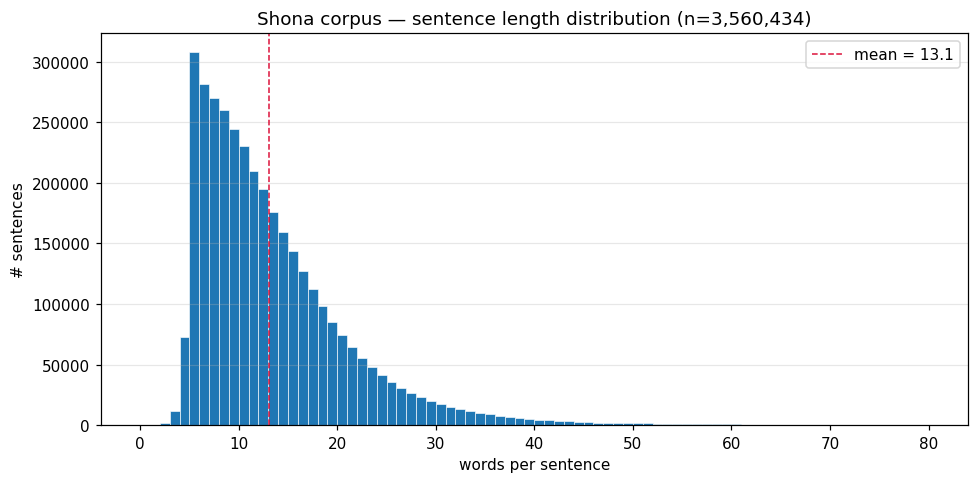

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5), dpi=110)
ax.hist(sentence_lengths, bins=80, range=(0, 80), edgecolor="white", linewidth=0.4)
ax.set_xlabel("words per sentence")
ax.set_ylabel("# sentences")
ax.set_title(f"Shona corpus — sentence length distribution (n={n_sentences:,})")
ax.axvline(headline["avg_words_per_sentence"], color="crimson", linestyle="--",
           linewidth=1, label=f"mean = {headline['avg_words_per_sentence']}")
ax.legend()
ax.grid(alpha=0.3, axis="y")
out_png = OUTDIR / "sentence_length_distribution.png"
fig.tight_layout()
fig.savefig(out_png, dpi=140)
print(f"Saved {out_png}")
plt.show()

Saved /Users/apple/Desktop/taurabot/data/processed/source_breakdown.png


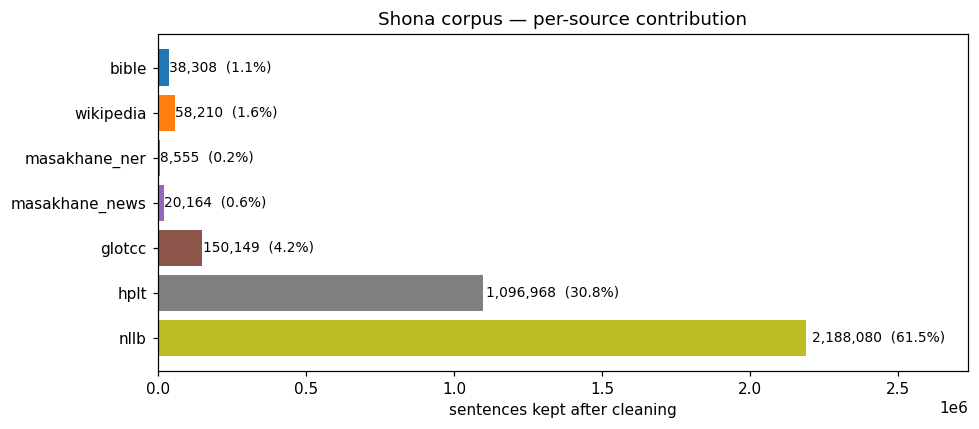

In [6]:
fig, ax = plt.subplots(figsize=(9, 4), dpi=110)
names = [s["source"] for s in per_source]
kept  = [s["sentences_kept"] for s in per_source]
colors = plt.cm.tab10([i / len(names) for i in range(len(names))])
bars = ax.barh(names, kept, color=colors)
for bar, n in zip(bars, kept):
    pct = 100 * n / stats["total_sentences"]
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
            f"{n:,}  ({pct:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("sentences kept after cleaning")
ax.set_title("Shona corpus — per-source contribution")
ax.set_xlim(0, max(kept) * 1.25)
ax.invert_yaxis()
out_png2 = OUTDIR / "source_breakdown.png"
fig.tight_layout()
fig.savefig(out_png2, dpi=140)
print(f"Saved {out_png2}")
plt.show()

## README-ready stats block

Writes a `readme_stats.md` snippet that can be pasted into the project README and the HuggingFace dataset card.

In [7]:
# Per-source license map — keep this aligned with configs/config.yaml license field.
LICENSES = {
    "bible":          "CC BY-SA 4.0 — © Biblica, Inc.",
    "wikipedia":      "CC BY-SA 3.0 — Wikipedia contributors",
    "masakhane_ner":  "AFL-3.0 — Masakhane NLP collective",
    "masakhane_news": "AFL-3.0 — Masakhane NLP collective",
    "glotcc":         "CC0-1.0 — cis-lmu GlotCC-V1",
    "hplt":           "CC0-1.0 — HPLT 2.0",
    "nllb":           "CC-BY-SA-4.0 — Facebook NLLB / OPUS",
}

lines = []
lines.append("## Corpus statistics\n")
lines.append("| Metric | Value |")
lines.append("|---|---:|")
lines.append(f"| Sentences | {n_sentences:,} |")
lines.append(f"| Words (whitespace-separated, ASCII) | {n_words:,} |")
lines.append(f"| Unique words (vocabulary) | {len(vocab):,} |")
lines.append(f"| Average sentence length | {headline['avg_words_per_sentence']:.1f} words |")
lines.append(f"| Corpus size | {headline['corpus_mb']:.1f} MB |")
lines.append("")
lines.append("### Per-source contribution\n")
lines.append("| Source | Raw lines | After cleaning | % kept | License |")
lines.append("|---|---:|---:|---:|---|")
for s in per_source:
    pct = 100 * s["sentences_kept"] / max(s["raw_lines"], 1)
    lic = LICENSES.get(s["source"], "?")
    lines.append(f"| `{s['source']}` | {s['raw_lines']:,} | {s['sentences_kept']:,} | {pct:.1f}% | {lic} |")
lines.append(f"| **Total** | | **{n_sentences:,}** | | combined ≈ CC BY-SA 4.0 |")
lines.append("")
lines.append("### Top 20 most frequent words\n")
lines.append("| Rank | Word | Count |")
lines.append("|---:|---|---:|")
for i, (w, c) in enumerate(top50[:20], 1):
    lines.append(f"| {i} | `{w}` | {c:,} |")

block = "\n".join(lines)
(OUTDIR / "readme_stats.md").write_text(block + "\n", encoding="utf-8")
print(f"Wrote {OUTDIR / 'readme_stats.md'}\n")
print("--- preview ---")
print(block)

Wrote /Users/apple/Desktop/taurabot/data/processed/readme_stats.md

--- preview ---
## Corpus statistics

| Metric | Value |
|---|---:|
| Sentences | 3,560,434 |
| Words (whitespace-separated, ASCII) | 46,625,305 |
| Unique words (vocabulary) | 1,489,240 |
| Average sentence length | 13.1 words |
| Corpus size | 360.5 MB |

### Per-source contribution

| Source | Raw lines | After cleaning | % kept | License |
|---|---:|---:|---:|---|
| `bible` | 31,103 | 38,308 | 123.2% | CC BY-SA 4.0 — © Biblica, Inc. |
| `wikipedia` | 115,575 | 58,210 | 50.4% | CC BY-SA 3.0 — Wikipedia contributors |
| `masakhane_ner` | 8,867 | 8,555 | 96.5% | AFL-3.0 — Masakhane NLP collective |
| `masakhane_news` | 3,684 | 20,164 | 547.3% | AFL-3.0 — Masakhane NLP collective |
| `glotcc` | 298,401 | 150,149 | 50.3% | CC0-1.0 — cis-lmu GlotCC-V1 |
| `hplt` | 1,201,596 | 1,096,968 | 91.3% | CC0-1.0 — HPLT 2.0 |
| `nllb` | 4,269,478 | 2,188,080 | 51.2% | CC-BY-SA-4.0 — Facebook NLLB / OPUS |
| **Total** | | **3,560,4